<a href="https://colab.research.google.com/github/Integenpiyush/churn-prediction-catboost/blob/main/notebooks/03_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install catboost optuna shap wandb imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, precision_score,
                              recall_score, classification_report,
                              RocCurveDisplay, ConfusionMatrixDisplay)

print("All imports successful")

All imports successful


In [28]:
# Load preprocessed data

with open('preprocessed_data.pkl','rb') as f:
  X_train,X_test,y_train,y_test = pickle.load(f)

print("Data loaded successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())
print("y_test distribution:", y_test.value_counts().to_dict())

Data loaded successfully
X_train shape: (8260, 29)
X_test shape: (1407, 29)
y_train distribution: {0: 4130, 1: 4130}
y_test distribution: {0: 1033, 1: 374}


## Day 10 — Baseline Model Comparison
Training 4 models with default parameters.
Goal: establish baseline performance before Optuna tuning.
Models: Logistic Regression, Random Forest, XGBoost, CatBoost
Primary metric: AUC-ROC (handles class imbalance well)
Secondary metric: F1-score (balances precision and recall)

In [29]:
# Define evaluation function
def evaluate_model(name,model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:,1]


  results = {'Model':name,
             'Accuracy':round(accuracy_score(y_test,y_pred),4),
             'Precision':round(precision_score(y_test,y_pred),4),
             'Recall':round(recall_score(y_test,y_pred),4),
             'F1':round(f1_score(y_test,y_pred),4),
             'AUC-ROC':round(roc_auc_score(y_test,y_prob),4)
  }

  print(f'\n{name} Results:')
  for k,v in results.items():
    if k!='Model':
      print(f'{k}:{v}')

  return results,model

In [30]:
# Train all 4 models
models = {
    'Logistic Regression':LogisticRegression(random_state=42,max_iter=1000),
    'Random Forest':RandomForestClassifier(random_state=42,n_jobs=-1),
    'XGBoost':XGBClassifier(random_state=42,eval_metric='logloss',verbosity=0),
    'CatBoost':CatBoostClassifier(random_state=42,verbose=0)
}
all_results = []
trained_models = {}

for name,model in models.items():
  results,trained = evaluate_model(name,model,X_train,X_test,y_train,y_test)
  all_results.append(results)
  trained_models[name] = trained

print("\nAll models trained successfully")


Logistic Regression Results:
Accuracy:0.7349
Precision:0.501
Recall:0.6979
F1:0.5832
AUC-ROC:0.8139

Random Forest Results:
Accuracy:0.7591
Precision:0.5406
Recall:0.623
F1:0.5789
AUC-ROC:0.7985

XGBoost Results:
Accuracy:0.7555
Precision:0.5338
Recall:0.6337
F1:0.5795
AUC-ROC:0.8074

CatBoost Results:
Accuracy:0.7576
Precision:0.5353
Recall:0.6684
F1:0.5945
AUC-ROC:0.8235

All models trained successfully


In [32]:
#  Comparison table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('AUC-ROC', ascending=False)


print("Model Comparison Table:")
print(results_df.to_string())

Model Comparison Table:
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
CatBoost               0.7576     0.5353  0.6684  0.5945   0.8235
Logistic Regression    0.7349     0.5010  0.6979  0.5832   0.8139
XGBoost                0.7555     0.5338  0.6337  0.5795   0.8074
Random Forest          0.7591     0.5406  0.6230  0.5789   0.7985


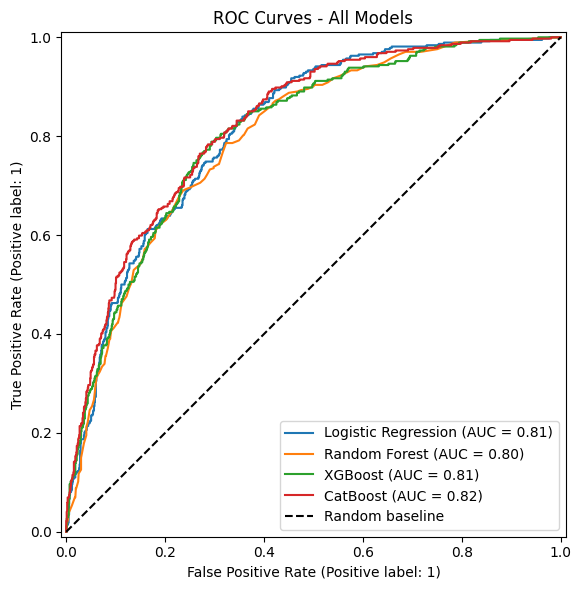

In [33]:
# ROC curves for all models
fig,ax = plt.subplots(figsize=(8,6))
for name,model in trained_models.items():
  RocCurveDisplay.from_estimator(model,X_test,y_test,ax=ax,name=name)

ax.plot([0,1],[0,1],'k--',label='Random baseline')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## Baseline Model Results

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC |
|-------|----------|-----------|--------|----|---------|
| CatBoost | 0.7576 | 0.5353 | 0.6684 | 0.5945 | 0.8235 |
| Logistic Regression | 0.7349 | 0.5010 | 0.6979 | 0.5832 | 0.8139 |
| XGBoost | 0.7555 | 0.5338 | 0.6337 | 0.5795 | 0.8074 |
| Random Forest | 0.7591 | 0.5406 | 0.6230 | 0.5789 | 0.7985 |

## Key Observations

1. CatBoost is best on AUC-ROC (0.8235) and F1 (0.5945) — proceeding with CatBoost for Optuna tuning

2. Random Forest has highest accuracy (0.7591) but lowest AUC-ROC (0.7985)
   — confirms accuracy is misleading for imbalanced problems

3. Logistic Regression has highest recall (0.6979) — catches most churners
   but at the cost of more false positives (lowest precision 0.5010)

4. All models show similar accuracy (~75%) because the test set
   is still imbalanced — SMOTE only helped training, not evaluation

## Why CatBoost over XGBoost?
- AUC-ROC: CatBoost 0.8235 vs XGBoost 0.8074 (+0.016)
- F1: CatBoost 0.5945 vs XGBoost 0.5795 (+0.015)
- CatBoost handles categorical features natively via ordered boosting
- Consistent improvement across both primary metrics confirms the choice

## Next Step
Optuna hyperparameter tuning on CatBoost — target AUC-ROC > 0.85

"Why did you choose CatBoost over XGBoost?"
"In my baseline comparison across 4 models, CatBoost achieved the highest AUC-ROC of 0.8235 and highest F1 of 0.5945. Beyond the numbers, CatBoost uses ordered boosting which reduces overfitting on smaller datasets, and handles categorical features natively without label encoding — which matters for this dataset with 16 categorical columns. The empirical results confirmed the theoretical advantage."